Exercise 8.12 : Implement KNN classification from scratch:	

In [6]:
## 	
## (a)	distance	computation

import math

def euclidean_distance(p1, p2):
    distance = 0
    
    for i in range(len(p1)):
        distance += (p1[i] - p2[i]) ** 2
        
    return math.sqrt(distance)

In [7]:
## (b) finding K nearest neighbors

def get_neighbors(X_train, y_train, test_point, k):
    
    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(X_train[i], test_point)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    return neighbors

In [8]:
## 	(c)	majority vote prediction

from collections import Counter

def predict_classification(X_train, y_train, test_point, k):

    neighbors = get_neighbors(X_train, y_train, test_point, k)

    labels = [neighbor[1] for neighbor in neighbors]

    prediction = Counter(labels).most_common(1)[0][0]

    return prediction

In [9]:
## (d)	test on Two	Moons with K= 1,5,15,50

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

# Generate dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Test different K values
for k in [1, 5, 15, 50]:

    predictions = []

    for point in X_test:
        pred = predict_classification(X_train.tolist(),
                                      y_train.tolist(),
                                      point.tolist(),
                                      k)
        predictions.append(pred)

    acc = accuracy_score(y_test, predictions)

    print(f"K = {k}, Accuracy = {acc:.2f}")

K = 1, Accuracy = 0.94
K = 5, Accuracy = 0.96
K = 15, Accuracy = 0.98
K = 50, Accuracy = 0.97


Exercise	8.13.	Implement	weighted	KNN	and	compare	decision	boundaries	with	and	
without	weighting	on	Two	Moons.

In [10]:
## 1. Weighted KNN Implementation
## Distance Function

import math

def euclidean_distance(p1, p2):

    distance = 0

    for i in range(len(p1)):
        distance += (p1[i] - p2[i]) ** 2

    return math.sqrt(distance)

In [11]:
#2. Weighted KNN Prediction
from collections import defaultdict

def weighted_knn_predict(X_train, y_train, test_point, k):

    distances = []

    # Compute distances
    for i in range(len(X_train)):

        dist = euclidean_distance(X_train[i], test_point)

        distances.append((dist, y_train[i]))

    # Sort by distance
    distances.sort(key=lambda x: x[0])

    # Select K nearest neighbors
    neighbors = distances[:k]

    # Weighted voting
    class_weights = defaultdict(float)

    for dist, label in neighbors:

        weight = 1 / (dist + 1e-5)

        class_weights[label] += weight

    # Prediction
    prediction = max(class_weights,
                     key=class_weights.get)

    return prediction

In [12]:
## 3. Testing on Two Moons Dataset
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_moons(n_samples=500,
                  noise=0.2,
                  random_state=42)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Predictions
predictions = []

k = 15

for point in X_test:

    pred = weighted_knn_predict(
        X_train.tolist(),
        y_train.tolist(),
        point.tolist(),
        k
    )

    predictions.append(pred)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Weighted KNN Accuracy:", accuracy)

Weighted KNN Accuracy: 0.98


Exercise	8.14.	Investigate	the	curse	of	dimensionality	empirically:	generate	data	in	d	
dimensions	with	two	Gaussian	clusters,	train	KNN	for	d	=	2,	5,	10,	20,	50,	100,	and	plot	
accuracy	vs.	dimension.	

Dimension = 2 Accuracy = 0.855
Dimension = 5 Accuracy = 0.975
Dimension = 10 Accuracy = 0.925
Dimension = 20 Accuracy = 1.0
Dimension = 50 Accuracy = 1.0
Dimension = 100 Accuracy = 1.0


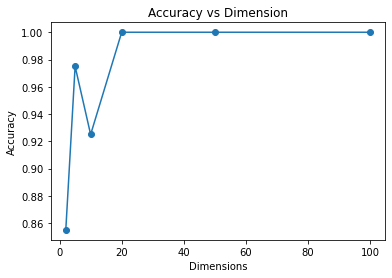

In [13]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Dimensions to test
dimensions = [2, 5, 10, 20, 50, 100]

accuracies = []

for d in dimensions:

    # Generate dataset
    X, y = make_blobs(
        n_samples=1000,
        centers=2,
        n_features=d,
        cluster_std=5,
        random_state=42
    )

    # Train-test split
    X_train, X_test, y_train, y_test = \
    train_test_split(
        X, y,
        test_size=0.2,
        random_state=42
    )

    # KNN model
    model = KNeighborsClassifier(
        n_neighbors=5
    )

    model.fit(X_train, y_train)

    # Prediction
    predictions = model.predict(X_test)

    # Accuracy
    acc = accuracy_score(
        y_test,
        predictions
    )

    accuracies.append(acc)

    print(
        "Dimension =", d,
        "Accuracy =", acc
    )

# Plot
plt.plot(
    dimensions,
    accuracies,
    marker='o'
)

plt.xlabel("Dimensions")
plt.ylabel("Accuracy")
plt.title(
    "Accuracy vs Dimension"
)

plt.show()

In [ ]:
Exercise	8.15.	Implement	KNN	regression	and	compare	with	linear	regression	on	a	noisy	
sine	wave	dataset.	

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

# Generate noisy sine wave data
X = np.linspace(0, 10, 200).reshape(-1, 1)

y = np.sin(X).ravel() + \
    np.random.normal(0, 0.2, 200)

# Models
knn = KNeighborsRegressor(
    n_neighbors=5
)

linear = LinearRegression()

# Train models
knn.fit(X, y)

linear.fit(X, y)

# Predictions
y_knn = knn.predict(X)

y_linear = linear.predict(X)

# Plot
plt.scatter(
    X,
    y,
    s=10,
    label="Data"
)

plt.plot(
    X,
    y_knn,
    label="KNN Regression"
)

plt.plot(
    X,
    y_linear,
    label="Linear Regression"
)

plt.legend()

plt.title(
    "KNN vs Linear Regression"
)

plt.show()